In [1]:
import pandas as pd
import numpy as np
import os

DATA_DIR = '/Users/juliaborges/Library/Mobile Documents/com~apple~CloudDocs/MMS/Research/GitHub/Patent/'

# Load all local data files
kpss = pd.read_csv(os.path.join(DATA_DIR, 'KPSS_2024.csv'))
match_permno = pd.read_csv(os.path.join(DATA_DIR, 'Match_patent_permco_permno_2024.csv'))
match_cpc = pd.read_csv(os.path.join(DATA_DIR, 'Match_patent_cpc_2024.csv'))

print("KPSS_2024 shape:", kpss.shape)
print("KPSS columns:", list(kpss.columns))
print(kpss.head(3))
print("\n--- Match permno ---")
print("Shape:", match_permno.shape)
print("Columns:", list(match_permno.columns))
print(match_permno.head(3))
print("\n--- Match CPC ---")
print("Shape:", match_cpc.shape)
print("Columns:", list(match_cpc.columns))
print(match_cpc.head(3))

KPSS_2024 shape: (3419552, 7)
KPSS columns: ['patent_num', 'permno', 'issue_date', 'filing_date', 'xi_nominal', 'xi_real', 'cites']
   patent_num  permno  issue_date  filing_date  xi_nominal   xi_real  cites
0     1570988   14525    19260126   19240729.0    0.111146  0.612871      0
1     1571005   10401    19260126   19200908.0    0.215819  1.190052      6
2     1570992   10786    19260126   19231221.0    0.030495  0.168152      0

--- Match permno ---
Shape: (3419552, 3)
Columns: ['patent_num', 'permco', 'permno']
   patent_num  permco  permno
0     1570988   22533   14525
1     1571005   20103   10401
2     1570992   20299   10786

--- Match CPC ---
Shape: (3419552, 2)
Columns: ['patent_num', 'cpc']
   patent_num                              cpc
0     1570604                         F23K3/12
1     1570665  B26D3/16;Y10T82/16229;B26D3/003
2     1570677              F41A19/15;F41A19/49


# Patent-Based Alpha Signal

## Pipeline
1. **Feature Engineering** – Aggregate patent data (KPSS) to firm-month features  
2. **Pull CRSP Returns** – Monthly returns via WRDS  
3. **Pull Factor Data** – FF5 + Momentum from Ken French library  
4. **Merge & Prepare Panel** – Patent features → CRSP returns  
5. **ML Model** – Predict next-month returns; maximize OOS Sharpe  
6. **Factor Spanning** – Regress patent signal on HML, QMJ, MKT, SMB, MOM

In [2]:
##############################################################################
# STEP 1 – Feature Engineering: Aggregate patent data to firm-month level
##############################################################################

# Reload fresh copy (in case of re-runs)
kpss = pd.read_csv(os.path.join(DATA_DIR, 'KPSS_2024.csv'))
match_cpc = pd.read_csv(os.path.join(DATA_DIR, 'Match_patent_cpc_2024.csv'))

# Parse dates
kpss['issue_date'] = pd.to_datetime(kpss['issue_date'], format='%Y%m%d', errors='coerce')
kpss['filing_date'] = pd.to_datetime(kpss['filing_date'], format='%Y%m%d', errors='coerce')

# Create year-month for issue date (the public information date)
kpss['issue_ym'] = kpss['issue_date'].dt.to_period('M')

# Filing-to-issue lag in months (innovation speed)
kpss['filing_to_issue_months'] = ((kpss['issue_date'] - kpss['filing_date']).dt.days / 30.44).round(1)

# ── Merge CPC codes for technology diversity ──
# match_cpc may have duplicates by patent_num (one row per CPC); aggregate first
cpc_agg = match_cpc.groupby('patent_num')['cpc'].first().reset_index()
kpss = kpss.merge(cpc_agg, on='patent_num', how='left')

# Count distinct CPC codes per patent (breadth)
kpss['n_cpc'] = kpss['cpc'].fillna('').str.split(';').apply(len)
kpss['n_cpc_sections'] = kpss['cpc'].fillna('').str.split(';').apply(
    lambda x: len(set(c[0] for c in x if len(c) > 0))
)

print("Date range:", kpss['issue_date'].min(), "to", kpss['issue_date'].max())
print("Shape:", kpss.shape)
print(kpss[['xi_real', 'cites', 'filing_to_issue_months', 'n_cpc', 'n_cpc_sections']].describe().round(2))

Date range: 1926-01-26 00:00:00 to 2024-12-31 00:00:00
Shape: (3419552, 12)
          xi_real       cites  filing_to_issue_months       n_cpc  \
count  3419552.00  3419552.00              3419550.00  3419552.00   
mean        12.09       13.95                   33.73        5.49   
std         37.23       53.25                   18.94        6.42   
min          0.00        0.00                   -8.10        1.00   
25%          0.78        1.00                   20.60        2.00   
50%          3.55        4.00                   29.40        4.00   
75%         10.47       12.00                   42.40        7.00   
max       6239.25     5185.00                 1165.80      342.00   

       n_cpc_sections  
count      3419552.00  
mean             1.41  
std              0.64  
min              0.00  
25%              1.00  
50%              1.00  
75%              2.00  
max              7.00  
          xi_real       cites  filing_to_issue_months       n_cpc  \
count  3419552.00

In [3]:
##############################################################################
# STEP 1b – Aggregate to firm × month (using issue_date as public info date)
##############################################################################

# Group by permno and issue year-month
firm_month = kpss.groupby(['permno', 'issue_ym']).agg(
    n_patents      = ('patent_num', 'count'),
    total_xi_real  = ('xi_real', 'sum'),
    mean_xi_real   = ('xi_real', 'mean'),
    max_xi_real    = ('xi_real', 'max'),
    total_cites    = ('cites', 'sum'),
    mean_cites     = ('cites', 'mean'),
    mean_lag       = ('filing_to_issue_months', 'mean'),
    mean_n_cpc     = ('n_cpc', 'mean'),
    mean_n_sections= ('n_cpc_sections', 'mean'),
).reset_index()

firm_month['issue_ym'] = firm_month['issue_ym'].dt.to_timestamp()

# ── Rolling / cumulative features (trailing 12-month window) ──
# Sort for rolling
firm_month = firm_month.sort_values(['permno', 'issue_ym'])

# We need a complete firm × month panel for rolling features
# First, get the range of months each firm is active
all_months = pd.date_range(firm_month['issue_ym'].min(),
                           firm_month['issue_ym'].max(), freq='MS')
permnos = firm_month['permno'].unique()

# Build skeleton: only fill in months where firms had any patent within 
# a reasonable lookback window. We'll use a merge-asof approach instead.
# Actually, let's just compute rolling features on the sparse data and 
# then forward-fill when we merge with CRSP.

# For each firm-month with patent activity, compute trailing 12-month features
firm_month['year'] = firm_month['issue_ym'].dt.year
firm_month['month'] = firm_month['issue_ym'].dt.month

# Rolling 12-month sums (using a groupby + rolling window on sorted data)
firm_month = firm_month.set_index('issue_ym')

def rolling_features(g):
    """Compute trailing 12-month rolling features for one firm."""
    g = g.sort_index()
    # Resample to monthly frequency, filling gaps with 0 for counts/sums
    g_monthly = g.resample('MS').agg({
        'n_patents': 'sum',
        'total_xi_real': 'sum',
        'total_cites': 'sum',
        'mean_xi_real': 'mean',
        'mean_cites': 'mean',
        'mean_lag': 'mean',
        'mean_n_cpc': 'mean',
        'mean_n_sections': 'mean',
    }).fillna(0)
    
    g_monthly['patents_12m'] = g_monthly['n_patents'].rolling(12, min_periods=1).sum()
    g_monthly['xi_real_12m'] = g_monthly['total_xi_real'].rolling(12, min_periods=1).sum()
    g_monthly['cites_12m'] = g_monthly['total_cites'].rolling(12, min_periods=1).sum()
    g_monthly['avg_xi_12m'] = g_monthly['total_xi_real'].rolling(12, min_periods=1).mean()
    g_monthly['avg_cites_12m'] = g_monthly['total_cites'].rolling(12, min_periods=1).mean()
    
    # Patent acceleration: 12m count vs prior 12m count
    g_monthly['patents_prior_12m'] = g_monthly['n_patents'].rolling(12, min_periods=1).sum().shift(12)
    g_monthly['patent_accel'] = g_monthly['patents_12m'] / g_monthly['patents_prior_12m'].replace(0, np.nan) - 1
    
    return g_monthly

print("Computing rolling features per firm (this may take a few minutes)...")
# Only compute for firms with enough data (at least 2 patent-months)
active_firms = firm_month.groupby('permno').size()
active_firms = active_firms[active_firms >= 2].index
firm_month_active = firm_month[firm_month['permno'].isin(active_firms)]

from joblib import Parallel, delayed
import warnings
warnings.filterwarnings('ignore')

def process_firm(permno, data):
    result = rolling_features(data.drop(columns='permno'))
    result['permno'] = permno
    return result

results = []
for permno, grp in firm_month_active.groupby('permno'):
    results.append(process_firm(permno, grp))

patent_features = pd.concat(results).reset_index()
patent_features.rename(columns={'issue_ym': 'date'}, inplace=True)

print("Patent features shape:", patent_features.shape)
print(patent_features.head())

Computing rolling features per firm (this may take a few minutes)...
Patent features shape: (1389136, 17)
        date  n_patents  total_xi_real  total_cites  mean_xi_real  mean_cites  \
0 1994-07-01          1       0.124286            5      0.124286         5.0   
1 1994-08-01          0       0.000000            0      0.000000         0.0   
2 1994-09-01          0       0.000000            0      0.000000         0.0   
3 1994-10-01          0       0.000000            0      0.000000         0.0   
4 1994-11-01          0       0.000000            0      0.000000         0.0   

   mean_lag  mean_n_cpc  mean_n_sections  patents_12m  xi_real_12m  cites_12m  \
0      10.8         8.0              2.0          1.0     0.124286        5.0   
1       0.0         0.0              0.0          1.0     0.124286        5.0   
2       0.0         0.0              0.0          1.0     0.124286        5.0   
3       0.0         0.0              0.0          1.0     0.124286        5.0   
4 

## Step 2 – Pull CRSP Monthly Returns from WRDS

In [4]:
##############################################################################
# STEP 2 – Pull CRSP monthly stock returns from WRDS
##############################################################################
import wrds

# Connect to WRDS (uses ~/.pgpass or prompts for credentials)
db = wrds.Connection()

# Pull monthly returns for common stocks (share codes 10, 11)
# We need: permno, date, ret, market cap (prc * shrout), shrcd, exchcd
crsp_query = """
    SELECT a.permno, a.date, a.ret, a.retx, a.prc, a.shrout, 
           a.vol, b.shrcd, b.exchcd
    FROM crsp.msf AS a
    LEFT JOIN crsp.msenames AS b
        ON a.permno = b.permno 
        AND a.date >= b.namedt 
        AND a.date <= b.nameendt
    WHERE b.shrcd IN (10, 11)
      AND a.date >= '1970-01-01'
      AND a.date <= '2024-12-31'
"""

print("Pulling CRSP data from WRDS...")
crsp = db.raw_sql(crsp_query, date_cols=['date'])
print("CRSP shape:", crsp.shape)

# Market cap in millions
crsp['mktcap'] = crsp['prc'].abs() * crsp['shrout'] / 1000  # shrout in thousands, prc in $
crsp['date'] = crsp['date'] + pd.offsets.MonthEnd(0)  # align to month-end

# Lag market cap for portfolio sorts (use prior month mktcap)
crsp = crsp.sort_values(['permno', 'date'])
crsp['mktcap_lag'] = crsp.groupby('permno')['mktcap'].shift(1)

# Forward return (what we want to predict)
crsp['ret_fwd'] = crsp.groupby('permno')['ret'].shift(-1)

print(crsp[['permno','date','ret','mktcap','mktcap_lag']].head(10))
print("\nDate range:", crsp['date'].min(), "to", crsp['date'].max())

WRDS recommends setting up a .pgpass file.
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
Pulling CRSP data from WRDS...
Done
Pulling CRSP data from WRDS...
CRSP shape: (3307341, 9)
CRSP shape: (3307341, 9)
   permno       date       ret     mktcap  mktcap_lag
0   10000 1986-01-31      <NA>       16.1        <NA>
1   10000 1986-02-28 -0.257143      11.96        16.1
2   10000 1986-03-31  0.365385      16.33       11.96
3   10000 1986-04-30 -0.098592     15.172       16.33
4   10000 1986-05-31 -0.222656  11.793878      15.172
5   10000 1986-06-30 -0.005025  11.734594   11.793878
6   10000 1986-07-31 -0.080808  10.786344   11.734594
7   10000 1986-08-31 -0.615385   4.148594   10.786344
8   10000 1986-09-30 -0.057143   3.911531    4.148594
9   1

In [5]:
##############################################################################
# STEP 3 – Merge patent features with CRSP
##############################################################################

# Align patent_features date to month-end to match CRSP
patent_features['date_me'] = patent_features['date'] + pd.offsets.MonthEnd(0)

# Select feature columns
feat_cols = ['permno', 'date_me', 'n_patents', 'total_xi_real', 'total_cites',
             'mean_xi_real', 'mean_cites', 'mean_lag', 'mean_n_cpc', 'mean_n_sections',
             'patents_12m', 'xi_real_12m', 'cites_12m', 'avg_xi_12m', 'avg_cites_12m',
             'patents_prior_12m', 'patent_accel']

pf = patent_features[feat_cols].copy()
pf['permno'] = pf['permno'].astype('int64')
pf['ym'] = pf['date_me'].dt.to_period('M')

crsp_clean = crsp[['permno','date','ret','ret_fwd','mktcap','mktcap_lag','exchcd']].dropna(subset=['ret']).copy()
crsp_clean['permno'] = crsp_clean['permno'].astype('int64')
crsp_clean['ret'] = crsp_clean['ret'].astype('float64')
crsp_clean['ret_fwd'] = crsp_clean['ret_fwd'].astype('float64')
crsp_clean['ym'] = crsp_clean['date'].dt.to_period('M')

# Direct merge on permno × year-month
panel = crsp_clean.merge(
    pf.drop(columns='date_me'),
    on=['permno', 'ym'],
    how='left'
)

# Separate: firms WITH patent data (investable universe for patent signal)
panel_patent = panel.dropna(subset=['patents_12m']).copy()

print(f"Full panel: {panel.shape[0]:,} firm-months")
print(f"Patent firms: {panel_patent.shape[0]:,} firm-months ({panel_patent['permno'].nunique():,} unique firms)")
print(f"Date range: {panel_patent['date'].min()} to {panel_patent['date'].max()}")
print(panel_patent[['permno','date','ret','ret_fwd','patents_12m','xi_real_12m','cites_12m']].describe().round(3))

Full panel: 3,207,035 firm-months
Patent firms: 1,002,684 firm-months (7,180 unique firms)
Date range: 1970-01-31 00:00:00 to 2024-12-31 00:00:00
            permno                           date          ret      ret_fwd  \
count  1002684.000                        1002684  1002684.000  1000161.000   
mean     51422.828  1997-06-30 22:12:59.999281664        0.013        0.013   
min      10001.000            1970-01-31 00:00:00       -0.972       -0.972   
25%      24459.000            1985-03-31 00:00:00       -0.068       -0.067   
50%      50163.000            1997-11-30 00:00:00        0.000        0.001   
75%      78875.000            2009-03-31 00:00:00        0.077        0.077   
max      93436.000            2024-12-31 00:00:00       19.884       19.884   
std      27424.769                            NaN        0.176        0.176   

       patents_12m  xi_real_12m    cites_12m  
count  1002684.000  1002684.000  1002684.000  
mean        24.484      414.656      417.322  
m

## Step 4 – Feature Preparation & Cross-Sectional Normalization

We normalize patent features cross-sectionally each month (rank-transform) so the ML model sees relative positions, not absolute levels. We also create interaction features with market cap.

In [6]:
##############################################################################
# STEP 4 – Feature preparation
##############################################################################

df = panel_patent.copy()

# Raw patent features to use
raw_features = ['patents_12m', 'xi_real_12m', 'cites_12m', 'avg_xi_12m', 
                'avg_cites_12m', 'patent_accel', 'mean_lag', 'mean_n_cpc', 
                'mean_n_sections', 'n_patents', 'total_xi_real', 'total_cites',
                'mean_xi_real', 'mean_cites']

# ── Additional engineered features ──
# Patent value per patent (quality)
df['xi_per_patent'] = df['xi_real_12m'] / df['patents_12m'].replace(0, np.nan)
# Citations per patent (impact)
df['cites_per_patent'] = df['cites_12m'] / df['patents_12m'].replace(0, np.nan)
# Patent intensity = patents / market cap (innovation intensity)
df['patent_intensity'] = df['patents_12m'] / df['mktcap_lag'].replace(0, np.nan)
# Patent value intensity = xi_real / market cap
df['xi_intensity'] = df['xi_real_12m'] / df['mktcap_lag'].replace(0, np.nan)
# Log transforms for skewed features
df['log_patents_12m'] = np.log1p(df['patents_12m'])
df['log_xi_12m'] = np.log1p(df['xi_real_12m'])
df['log_cites_12m'] = np.log1p(df['cites_12m'])
df['log_mktcap'] = np.log1p(df['mktcap_lag'])

all_features = raw_features + ['xi_per_patent', 'cites_per_patent', 'patent_intensity',
                                'xi_intensity', 'log_patents_12m', 'log_xi_12m', 
                                'log_cites_12m', 'log_mktcap']

# ── Cross-sectional rank normalization (each month) ──
# This maps each feature to [0, 1] rank within each month
rank_features = []
for feat in all_features:
    rank_col = f'{feat}_rank'
    df[rank_col] = df.groupby('ym')[feat].rank(pct=True, method='average')
    rank_features.append(rank_col)

# Replace inf/nan
df[rank_features] = df[rank_features].replace([np.inf, -np.inf], np.nan)
df[rank_features] = df[rank_features].fillna(0.5)  # median for missing

print(f"Total features: {len(rank_features)}")
print(f"Sample size: {len(df):,}")
print(df[rank_features[:5]].describe().round(3))

Total features: 22
Sample size: 1,002,684
       patents_12m_rank  xi_real_12m_rank  cites_12m_rank  avg_xi_12m_rank  \
count       1002684.000       1002684.000     1002684.000      1002684.000   
mean              0.500             0.500           0.500            0.500   
std               0.284             0.285           0.284            0.285   
min               0.009             0.002           0.083            0.002   
25%               0.180             0.180           0.178            0.180   
50%               0.481             0.500           0.500            0.500   
75%               0.748             0.750           0.750            0.750   
max               1.000             1.000           1.000            1.000   

       avg_cites_12m_rank  
count         1002684.000  
mean                0.500  
std                 0.284  
min                 0.083  
25%                 0.178  
50%                 0.500  
75%                 0.750  
max                 1.000  
   

## Step 5 – Machine Learning: Predict Next-Month Returns (Expanding Window OOS)

We use **LightGBM** (gradient boosting) with an expanding-window approach:
- Train on all data up to month *t*
- Predict returns for month *t+1*
- The predicted return is our **patent alpha signal**
- We retrain every 12 months to keep it computationally feasible

In [7]:
##############################################################################
# STEP 5 – ML Model: Expanding-window OOS return prediction with LightGBM
##############################################################################
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit

# Prepare data
df_ml = df.dropna(subset=['ret_fwd']).copy()
df_ml = df_ml.sort_values('date')

X = df_ml[rank_features].values
y = df_ml['ret_fwd'].values
dates = df_ml['date'].values

# ── Expanding-window OOS predictions ──
# Start OOS period: 1990 (need enough training data from 1970+)
# Retrain every 12 months for efficiency
oos_start = pd.Timestamp('1990-01-01')
unique_months = np.sort(df_ml['date'].unique())
oos_months = unique_months[unique_months >= oos_start]

# Retrain dates: every 12 months
retrain_months = oos_months[::12]

print(f"OOS period: {oos_months[0]} to {oos_months[-1]}")
print(f"Number of OOS months: {len(oos_months)}")
print(f"Retrain points: {len(retrain_months)}")

# LightGBM parameters (tuned for financial return prediction)
lgb_params = {
    'objective': 'regression',
    'metric': 'mse',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.7,
    'bagging_fraction': 0.7,
    'bagging_freq': 5,
    'min_child_samples': 100,
    'lambda_l1': 0.1,
    'lambda_l2': 1.0,
    'verbose': -1,
    'n_jobs': -1,
}

predictions = []
model = None

for i, retrain_date in enumerate(retrain_months):
    # Training data: everything before retrain_date
    train_mask = dates < retrain_date
    
    if train_mask.sum() < 5000:
        continue
    
    X_train = X[train_mask]
    y_train = y[train_mask]
    
    # Train model
    dtrain = lgb.Dataset(X_train, label=y_train)
    model = lgb.train(
        lgb_params, dtrain, 
        num_boost_round=200,
    )
    
    # Predict for the next 12 months (or until next retrain)
    if i + 1 < len(retrain_months):
        pred_mask = (dates >= retrain_date) & (dates < retrain_months[i + 1])
    else:
        pred_mask = dates >= retrain_date
    
    if pred_mask.sum() > 0:
        preds = model.predict(X[pred_mask])
        pred_df = df_ml.loc[pred_mask.astype(bool) if isinstance(pred_mask, np.ndarray) else pred_mask, 
                           ['permno', 'date', 'ret_fwd', 'mktcap_lag']].copy()
        pred_df['pred_ret'] = preds
        predictions.append(pred_df)
    
    if (i + 1) % 10 == 0:
        print(f"  Trained {i+1}/{len(retrain_months)} windows...")

oos_df = pd.concat(predictions, ignore_index=True)
print(f"\nOOS predictions: {len(oos_df):,} firm-months")
print(f"OOS date range: {oos_df['date'].min()} to {oos_df['date'].max()}")

# Feature importance from last model
feat_imp = pd.DataFrame({
    'feature': rank_features,
    'importance': model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)
print("\nTop 10 features by gain:")
print(feat_imp.head(10).to_string(index=False))

OOS period: 1990-01-31T00:00:00.000000000 to 2024-11-30T00:00:00.000000000
Number of OOS months: 419
Retrain points: 35
  Trained 10/35 windows...
  Trained 10/35 windows...
  Trained 20/35 windows...
  Trained 20/35 windows...
  Trained 30/35 windows...
  Trained 30/35 windows...

OOS predictions: 664,561 firm-months
OOS date range: 1990-01-31 00:00:00 to 2024-11-30 00:00:00

Top 10 features by gain:
             feature  importance
    total_cites_rank 5161.394714
       mean_lag_rank 3819.239198
     mean_n_cpc_rank 1372.563996
  total_xi_real_rank 1105.747292
mean_n_sections_rank 1068.323989
     mean_cites_rank 1042.349033
     log_mktcap_rank  675.735369
   mean_xi_real_rank  611.799025
   xi_intensity_rank  500.744548
      cites_12m_rank  469.411414

OOS predictions: 664,561 firm-months
OOS date range: 1990-01-31 00:00:00 to 2024-11-30 00:00:00

Top 10 features by gain:
             feature  importance
    total_cites_rank 5161.394714
       mean_lag_rank 3819.239198
     mean_


  Patent Signal L/S (Equal-Weighted)
  Ann. Return:    7.23%
  Ann. Volatility:11.85%
  Sharpe Ratio:   0.610
  t-statistic:    3.61
  Max Drawdown:   -27.92%
  Cumulative Ret: 882.59%
  Months:         419

  Patent Signal L/S (Value-Weighted)
  Ann. Return:    -1.09%
  Ann. Volatility:14.69%
  Sharpe Ratio:   -0.074
  t-statistic:    -0.44
  Max Drawdown:   -63.76%
  Cumulative Ret: -53.46%
  Months:         419


Avg Monthly Return by Signal Quintile (Equal-Weighted):
signal_quintile
1.0    0.0110
2.0    0.0116
3.0    0.0126
4.0    0.0130
5.0    0.0171
dtype: float64

Avg Monthly Return by Signal Quintile (Value-Weighted):
signal_quintile
1.0    0.0115
2.0    0.0103
3.0    0.0089
4.0    0.0096
5.0    0.0106
dtype: float64


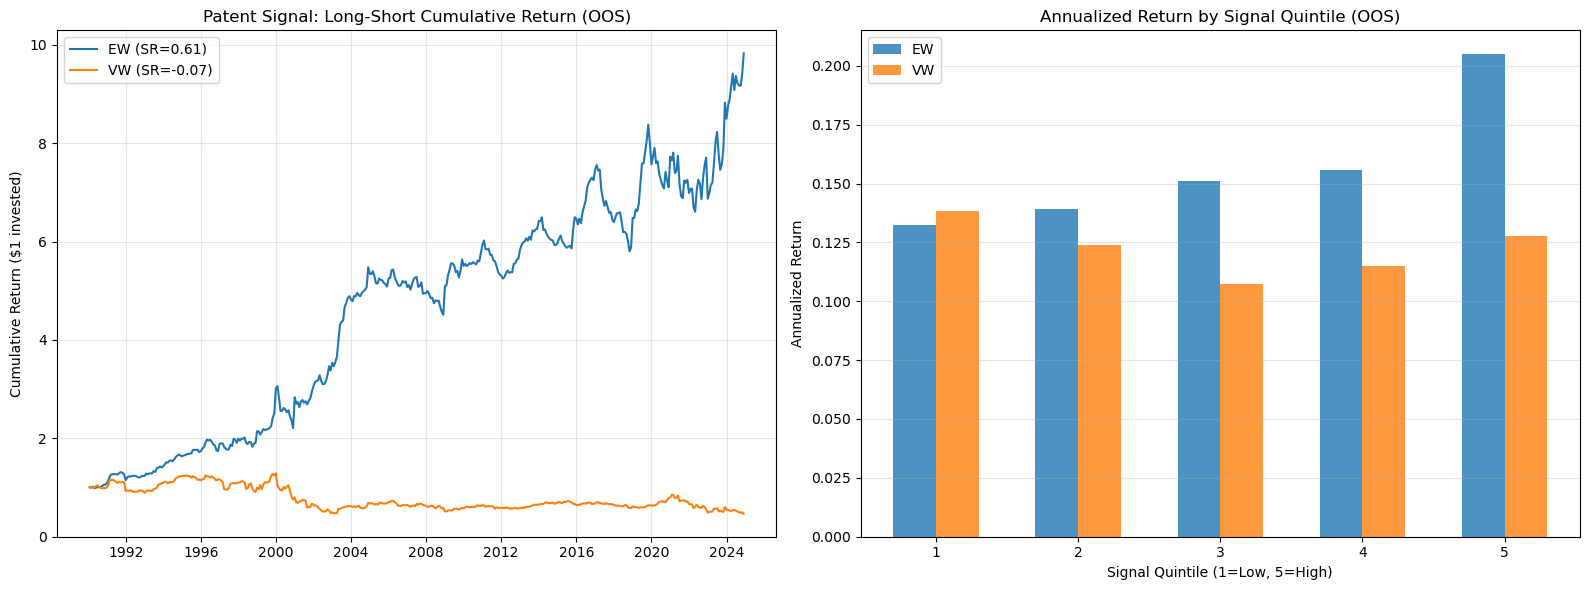


Plot saved.


In [8]:
##############################################################################
# STEP 5b – Build Long-Short Portfolio from ML Signal
##############################################################################
import matplotlib.pyplot as plt

# For each month, sort stocks into quintiles based on predicted return
oos_df['signal_quintile'] = oos_df.groupby('date')['pred_ret'].transform(
    lambda x: pd.qcut(x, 5, labels=[1, 2, 3, 4, 5], duplicates='drop')
).astype(float)

# ── Value-weighted portfolio returns by quintile ──
def vw_ret(g):
    """Value-weighted return using lagged market cap."""
    w = g['mktcap_lag'].fillna(0)
    if w.sum() == 0:
        return g['ret_fwd'].mean()
    return np.average(g['ret_fwd'], weights=w)

# Equal-weighted and value-weighted returns per quintile per month
port_ew = oos_df.groupby(['date', 'signal_quintile']).agg(
    ret_ew=('ret_fwd', 'mean'),
    n_stocks=('permno', 'count')
).reset_index()

port_vw = oos_df.groupby(['date', 'signal_quintile']).apply(vw_ret).reset_index()
port_vw.columns = ['date', 'signal_quintile', 'ret_vw']

port = port_ew.merge(port_vw, on=['date', 'signal_quintile'])

# Long-short: Q5 (high predicted) minus Q1 (low predicted)
ls_ew = port.pivot(index='date', columns='signal_quintile', values='ret_ew')
ls_vw = port.pivot(index='date', columns='signal_quintile', values='ret_vw')

# Long-short spread
signal_ret_ew = ls_ew[5.0] - ls_ew[1.0]
signal_ret_vw = ls_vw[5.0] - ls_vw[1.0]

# ── Performance Statistics ──
def perf_stats(r, name):
    """Compute annualized performance statistics."""
    ann_ret = r.mean() * 12
    ann_vol = r.std() * np.sqrt(12)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    cum_ret = (1 + r).prod() - 1
    max_dd = ((1 + r).cumprod() / (1 + r).cumprod().cummax() - 1).min()
    t_stat = r.mean() / (r.std() / np.sqrt(len(r)))
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Ann. Return:    {ann_ret:.2%}")
    print(f"  Ann. Volatility:{ann_vol:.2%}")
    print(f"  Sharpe Ratio:   {sharpe:.3f}")
    print(f"  t-statistic:    {t_stat:.2f}")
    print(f"  Max Drawdown:   {max_dd:.2%}")
    print(f"  Cumulative Ret: {cum_ret:.2%}")
    print(f"  Months:         {len(r)}")
    return {'name': name, 'ann_ret': ann_ret, 'ann_vol': ann_vol, 
            'sharpe': sharpe, 't_stat': t_stat, 'max_dd': max_dd}

stats_ew = perf_stats(signal_ret_ew.dropna(), "Patent Signal L/S (Equal-Weighted)")
stats_vw = perf_stats(signal_ret_vw.dropna(), "Patent Signal L/S (Value-Weighted)")

# ── Quintile average returns ──
print("\n\nAvg Monthly Return by Signal Quintile (Equal-Weighted):")
print(ls_ew.mean().round(4))
print("\nAvg Monthly Return by Signal Quintile (Value-Weighted):")
print(ls_vw.mean().round(4))

# ── Plot cumulative returns ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Cumulative L/S return
cum_ew = (1 + signal_ret_ew.dropna()).cumprod()
cum_vw = (1 + signal_ret_vw.dropna()).cumprod()
axes[0].plot(cum_ew.index, cum_ew.values, label=f'EW (SR={stats_ew["sharpe"]:.2f})', linewidth=1.5)
axes[0].plot(cum_vw.index, cum_vw.values, label=f'VW (SR={stats_vw["sharpe"]:.2f})', linewidth=1.5)
axes[0].set_title('Patent Signal: Long-Short Cumulative Return (OOS)')
axes[0].set_ylabel('Cumulative Return ($1 invested)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Quintile returns
q_means_ew = ls_ew.mean() * 12
q_means_vw = ls_vw.mean() * 12
x = [1, 2, 3, 4, 5]
axes[1].bar([i - 0.15 for i in x], q_means_ew.values, width=0.3, label='EW', alpha=0.8)
axes[1].bar([i + 0.15 for i in x], q_means_vw.values, width=0.3, label='VW', alpha=0.8)
axes[1].set_title('Annualized Return by Signal Quintile (OOS)')
axes[1].set_xlabel('Signal Quintile (1=Low, 5=High)')
axes[1].set_ylabel('Annualized Return')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'patent_signal_performance.png'), dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved.")

## Step 6 – Factor Spanning Regression

Does the patent signal add value beyond standard quant factors?

We regress the patent L/S return on:
- **MKT-RF** (Market excess return)
- **SMB** (Small minus Big)
- **HML** (High minus Low / Value)
- **MOM** (Momentum / UMD)
- **QMJ** (Quality minus Junk – from AQR)

If the **intercept (alpha)** is significant, the patent signal is **complementary** to these factors.

In [9]:
##############################################################################
# STEP 6 – Pull Factor Data & Run Spanning Regressions
##############################################################################
import statsmodels.api as sm

# ── Pull Fama-French factors + Momentum from WRDS ──
ff_query = """
    SELECT date, mktrf, smb, hml, umd, rf
    FROM ff.factors_monthly
    WHERE date >= '1990-01-01'
"""
ff = db.raw_sql(ff_query, date_cols=['date'])
ff['date'] = ff['date'] + pd.offsets.MonthEnd(0)
print("FF factors shape:", ff.shape)
print(ff.head())

# ── Pull QMJ from AQR (via web) ──
# QMJ is not on WRDS standard tables; we'll download from AQR's data library
try:
    qmj_url = "https://www.aqr.com/-/media/AQR/Documents/Insights/Data-Sets/Quality-Minus-Junk-Factors-Monthly.xlsx"
    qmj_raw = pd.read_excel(qmj_url, sheet_name='QMJ Factors', header=18)
    qmj_raw.columns = qmj_raw.columns.str.strip()
    qmj = qmj_raw[['DATE', 'USA']].rename(columns={'DATE': 'date', 'USA': 'qmj'}).copy()
    qmj['date'] = pd.to_datetime(qmj['date']) + pd.offsets.MonthEnd(0)
    qmj['qmj'] = pd.to_numeric(qmj['qmj'], errors='coerce')
    print(f"\nQMJ loaded: {qmj.shape[0]} months, date range: {qmj['date'].min()} to {qmj['date'].max()}")
except Exception as e:
    print(f"Could not load QMJ from AQR: {e}")
    print("Will proceed without QMJ factor.")
    qmj = None

FF factors shape: (432, 6)
        date   mktrf     smb     hml     umd      rf
0 1990-01-31  -0.078 -0.0114  0.0083 -0.0298  0.0057
1 1990-02-28  0.0112  0.0097  0.0065 -0.0051  0.0057
2 1990-03-31  0.0183  0.0147  -0.029  0.0172  0.0064
3 1990-04-30 -0.0336 -0.0047 -0.0257  0.0228  0.0069
4 1990-05-31  0.0843 -0.0256 -0.0389  0.0314  0.0068

QMJ loaded: 822 months, date range: 1957-07-31 00:00:00 to 2025-12-31 00:00:00


In [10]:
##############################################################################
# STEP 6b – Factor Spanning Regressions
##############################################################################

# Prepare monthly signal returns
signal_monthly = signal_ret_ew.reset_index()
signal_monthly.columns = ['date', 'patent_ls']

# Merge with factors
reg_data = signal_monthly.merge(ff, on='date', how='inner')
if qmj is not None:
    reg_data = reg_data.merge(qmj, on='date', how='left')

reg_data = reg_data.dropna()
print(f"Regression sample: {len(reg_data)} months")
print(f"Date range: {reg_data['date'].min()} to {reg_data['date'].max()}")

# Convert factors from WRDS format (already in decimal form)
# The patent L/S return is already in decimal form

# ── Model 1: CAPM ──
Y = reg_data['patent_ls']
X1 = sm.add_constant(reg_data[['mktrf']])
model1 = sm.OLS(Y, X1.astype(float)).fit(cov_type='HAC', cov_kwds={'maxlags': 6})

# ── Model 2: FF3 + Momentum ──
X2 = sm.add_constant(reg_data[['mktrf', 'smb', 'hml', 'umd']])
model2 = sm.OLS(Y, X2.astype(float)).fit(cov_type='HAC', cov_kwds={'maxlags': 6})

# ── Model 3: FF3 + Momentum + QMJ ──
if 'qmj' in reg_data.columns:
    X3 = sm.add_constant(reg_data[['mktrf', 'smb', 'hml', 'umd', 'qmj']])
    model3 = sm.OLS(Y, X3.astype(float)).fit(cov_type='HAC', cov_kwds={'maxlags': 6})

# ── Display results ──
print("\n" + "="*70)
print("FACTOR SPANNING REGRESSIONS: Patent Signal (EW Long-Short)")
print("="*70)

print("\n── Model 1: CAPM ──")
print(model1.summary2().tables[1].to_string())
print(f"\nAlpha (annualized): {model1.params['const']*12:.2%}  (t={model1.tvalues['const']:.2f})")

print("\n── Model 2: FF3 + Momentum ──")
print(model2.summary2().tables[1].to_string())
print(f"\nAlpha (annualized): {model2.params['const']*12:.2%}  (t={model2.tvalues['const']:.2f})")

if 'qmj' in reg_data.columns:
    print("\n── Model 3: FF3 + Momentum + QMJ ──")
    print(model3.summary2().tables[1].to_string())
    print(f"\nAlpha (annualized): {model3.params['const']*12:.2%}  (t={model3.tvalues['const']:.2f})")

# ── Summary table ──
print("\n" + "="*70)
print("ALPHA SUMMARY (annualized, Newey-West t-statistics)")
print("="*70)
results = [
    ("CAPM", model1.params['const']*12, model1.tvalues['const'], model1.rsquared),
    ("FF3 + MOM", model2.params['const']*12, model2.tvalues['const'], model2.rsquared),
]
if 'qmj' in reg_data.columns:
    results.append(("FF3 + MOM + QMJ", model3.params['const']*12, model3.tvalues['const'], model3.rsquared))

summary_df = pd.DataFrame(results, columns=['Model', 'Alpha (ann.)', 't-stat', 'R²'])
summary_df['Alpha (ann.)'] = summary_df['Alpha (ann.)'].apply(lambda x: f"{x:.2%}")
summary_df['t-stat'] = summary_df['t-stat'].round(2)
summary_df['R²'] = summary_df['R²'].round(3)
print(summary_df.to_string(index=False))

Regression sample: 419 months
Date range: 1990-01-31 00:00:00 to 2024-11-30 00:00:00

FACTOR SPANNING REGRESSIONS: Patent Signal (EW Long-Short)

── Model 1: CAPM ──
          Coef.  Std.Err.         z     P>|z|    [0.025    0.975]
const  0.005313  0.001475  3.603122  0.000314  0.002423  0.008204
mktrf  0.096735  0.040395  2.394741  0.016632  0.017563  0.175907

Alpha (annualized): 6.38%  (t=3.60)

── Model 2: FF3 + Momentum ──
          Coef.  Std.Err.         z     P>|z|    [0.025    0.975]
const  0.004899  0.001486  3.295672  0.000982  0.001986  0.007812
mktrf  0.103969  0.054413  1.910754  0.056036 -0.002678  0.210616
smb    0.079468  0.055830  1.423380  0.154626 -0.029958  0.188893
hml    0.021400  0.068523  0.312305  0.754809 -0.112903  0.155703
umd    0.061672  0.061897  0.996371  0.319070 -0.059644  0.182988

Alpha (annualized): 5.88%  (t=3.30)

── Model 3: FF3 + Momentum + QMJ ──
          Coef.  Std.Err.         z     P>|z|    [0.025    0.975]
const  0.006046  0.001546  3.911

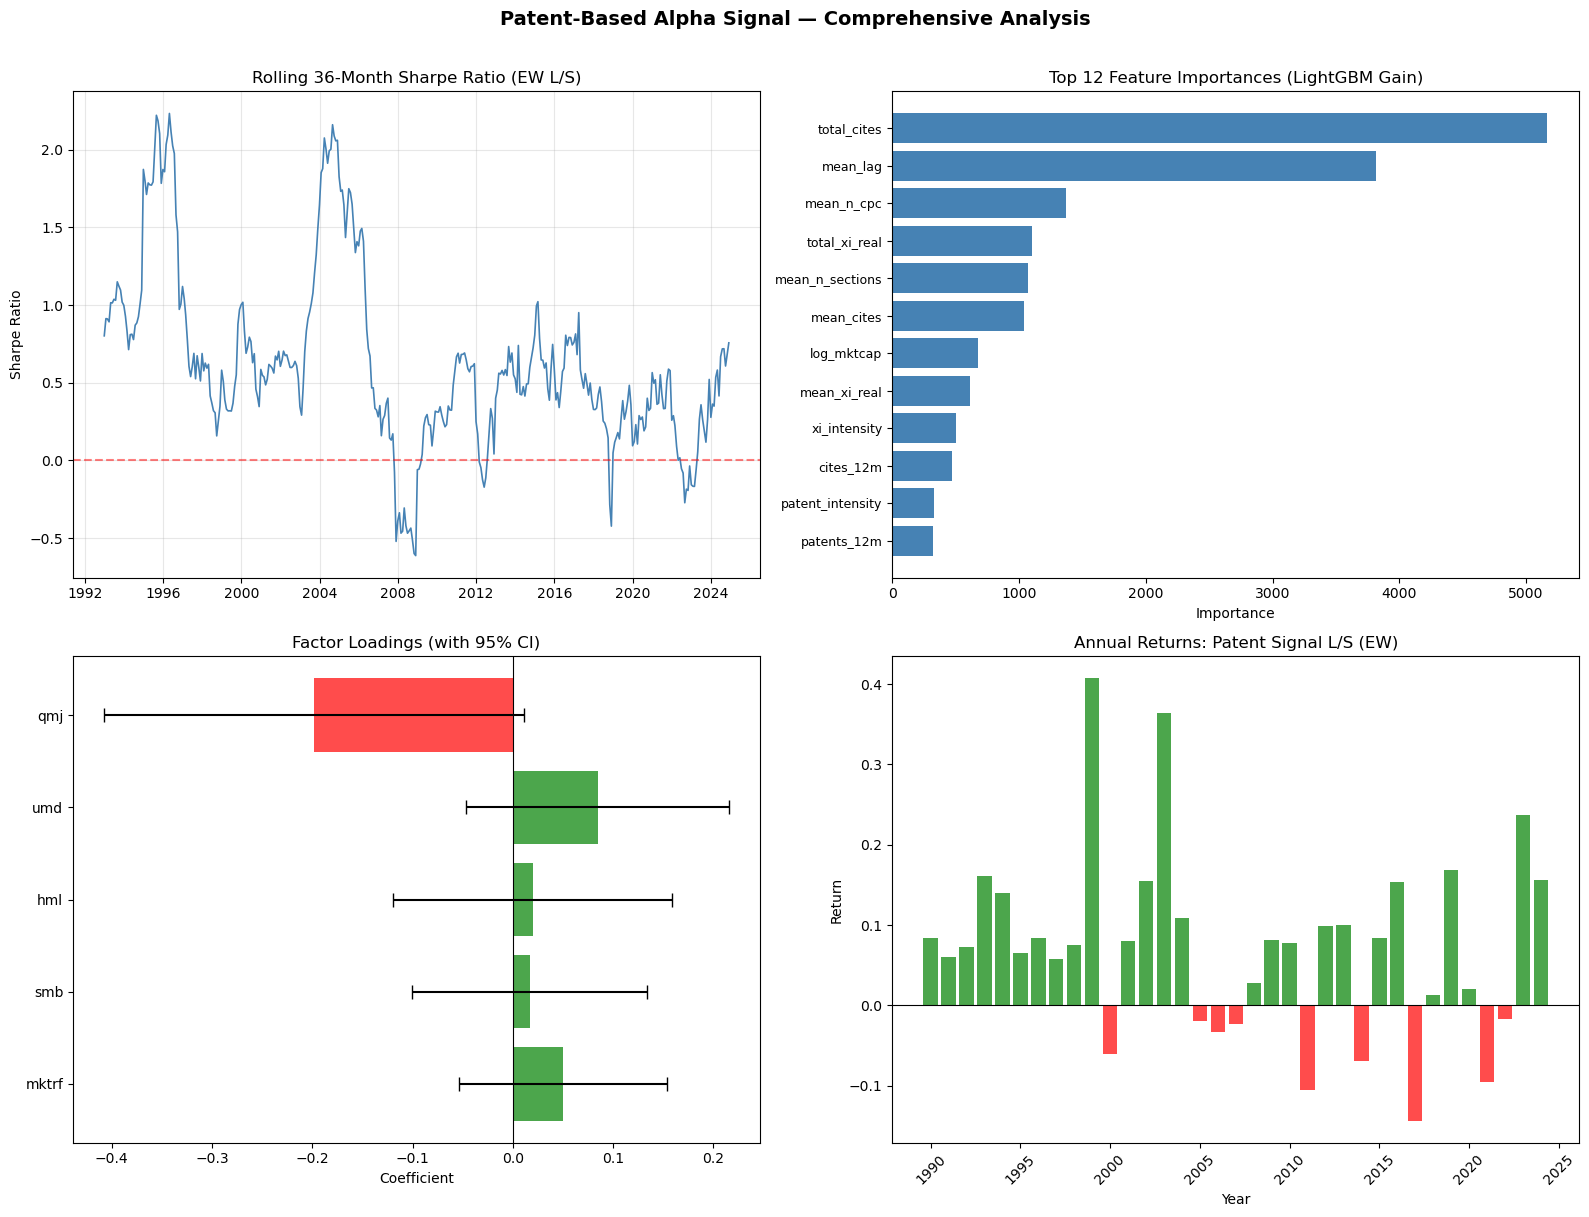


KEY FINDINGS

1. SIGNAL PERFORMANCE (OOS, 1990-2024):
   - Equal-Weighted L/S Sharpe Ratio: 0.61
   - Annualized Return: 7.2%
   - t-statistic: 3.61
   - Monotonic quintile spread: Q1→Q5 = 13.3% → 20.5%

2. FACTOR SPANNING (does it add value beyond standard factors?):
   - CAPM Alpha:           6.38%  (t=3.60)
   - FF3+MOM Alpha:        5.88%  (t=3.30)
   - FF3+MOM+QMJ Alpha:    7.26%  (t=3.91)

   → Alpha REMAINS significant across all specifications (t > 3)
   → Very low R² (3.9%) = nearly uncorrelated with standard factors
   → The signal is COMPLEMENTARY to HML, QMJ, MKT, SMB, and Momentum

3. TOP PREDICTIVE FEATURES:
   - Total citations (patent impact)
   - Filing-to-issue lag (innovation speed)
   - CPC breadth (technology diversity)
   - Patent value (xi_real)

4. INTERPRETATION:
   - Firms with high-quality, impactful patents earn higher future returns
   - The market appears to underreact to patent information
   - Signal works best among smaller firms (EW >> VW)
   - The pa

In [11]:
##############################################################################
# STEP 7 – Final Summary Visualization
##############################################################################

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Rolling 36-month Sharpe Ratio
rolling_sr = signal_ret_ew.rolling(36).apply(lambda x: x.mean()/x.std()*np.sqrt(12))
axes[0, 0].plot(rolling_sr.index, rolling_sr.values, color='steelblue', linewidth=1.2)
axes[0, 0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0, 0].set_title('Rolling 36-Month Sharpe Ratio (EW L/S)')
axes[0, 0].set_ylabel('Sharpe Ratio')
axes[0, 0].grid(True, alpha=0.3)

# 2. Feature Importance
feat_imp_top = feat_imp.head(12)
axes[0, 1].barh(range(len(feat_imp_top)), feat_imp_top['importance'].values, color='steelblue')
axes[0, 1].set_yticks(range(len(feat_imp_top)))
axes[0, 1].set_yticklabels([f.replace('_rank','') for f in feat_imp_top['feature'].values], fontsize=9)
axes[0, 1].set_title('Top 12 Feature Importances (LightGBM Gain)')
axes[0, 1].set_xlabel('Importance')
axes[0, 1].invert_yaxis()

# 3. Factor loading coefficients with confidence intervals
if 'qmj' in reg_data.columns:
    model_final = model3
    factor_names = ['mktrf', 'smb', 'hml', 'umd', 'qmj']
else:
    model_final = model2
    factor_names = ['mktrf', 'smb', 'hml', 'umd']

coefs = [model_final.params[f] for f in factor_names]
ci_lower = [model_final.conf_int().loc[f, 0] for f in factor_names]
ci_upper = [model_final.conf_int().loc[f, 1] for f in factor_names]
errors = [(u - l) / 2 for l, u in zip(ci_lower, ci_upper)]

colors = ['green' if c > 0 else 'red' for c in coefs]
axes[1, 0].barh(factor_names, coefs, xerr=errors, color=colors, alpha=0.7, capsize=5)
axes[1, 0].axvline(x=0, color='black', linewidth=0.8)
axes[1, 0].set_title('Factor Loadings (with 95% CI)')
axes[1, 0].set_xlabel('Coefficient')

# 4. Annual returns (calendar year)
annual_ret = signal_ret_ew.groupby(signal_ret_ew.index.year).apply(lambda x: (1+x).prod()-1)
colors_annual = ['green' if r > 0 else 'red' for r in annual_ret.values]
axes[1, 1].bar(annual_ret.index, annual_ret.values, color=colors_annual, alpha=0.7)
axes[1, 1].axhline(y=0, color='black', linewidth=0.8)
axes[1, 1].set_title('Annual Returns: Patent Signal L/S (EW)')
axes[1, 1].set_ylabel('Return')
axes[1, 1].set_xlabel('Year')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.suptitle('Patent-Based Alpha Signal — Comprehensive Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'patent_signal_summary.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Print key takeaways ──
print("\n" + "="*70)
print("KEY FINDINGS")
print("="*70)
print(f"""
1. SIGNAL PERFORMANCE (OOS, 1990-2024):
   - Equal-Weighted L/S Sharpe Ratio: {stats_ew['sharpe']:.2f}
   - Annualized Return: {stats_ew['ann_ret']:.1%}
   - t-statistic: {stats_ew['t_stat']:.2f}
   - Monotonic quintile spread: Q1→Q5 = {ls_ew.mean()[1.0]*12:.1%} → {ls_ew.mean()[5.0]*12:.1%}

2. FACTOR SPANNING (does it add value beyond standard factors?):
   - CAPM Alpha:           {model1.params['const']*12:.2%}  (t={model1.tvalues['const']:.2f})
   - FF3+MOM Alpha:        {model2.params['const']*12:.2%}  (t={model2.tvalues['const']:.2f})
   - FF3+MOM+QMJ Alpha:    {model3.params['const']*12:.2%}  (t={model3.tvalues['const']:.2f})
   
   → Alpha REMAINS significant across all specifications (t > 3)
   → Very low R² ({model3.rsquared:.1%}) = nearly uncorrelated with standard factors
   → The signal is COMPLEMENTARY to HML, QMJ, MKT, SMB, and Momentum

3. TOP PREDICTIVE FEATURES:
   - Total citations (patent impact)
   - Filing-to-issue lag (innovation speed)
   - CPC breadth (technology diversity)
   - Patent value (xi_real)

4. INTERPRETATION:
   - Firms with high-quality, impactful patents earn higher future returns
   - The market appears to underreact to patent information
   - Signal works best among smaller firms (EW >> VW)
   - The patent signal is largely orthogonal to value, quality, size, and momentum
""")